In [59]:
#%%

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Define capability benchmarks
cap_names = ['bbh',
 'lambada_openai',
 'logiqa',
 'medqa_4options',
 'minerva_math',
 'piqa',
 'gsm8k',
 'hellaswag',
 'arc_challenge',
 'mmlu',
 'winogrande']

# ["logiqa", "piqa", "hellaswag", "winogrande", 'superglue_copa', "medqa_4options", "arc_challenge", "mmlu", "minerva_math", "lambada_openai", "gsm8k", "bbh"]

# common_sense = ['logiqa', 'piqa', 'hellaswag', 'winogrande', 'superglue_copa', 'lambada_openai', 'bbh']
# math = ['minerva_math', 'gsm8k']
# knowledge = ['mmlu', 'medqa_4options', 'arc_challenge']
# cap_names = math

def load_data():
    """
    Load data from CSV files and return as pandas DataFrames.
    """
    base_model_df = pd.read_csv('data/benchmarks_base_models.csv', index_col='model')
    chat_model_df = pd.read_csv('data/benchmarks_chat_models.csv', index_col='model')
    evals_df = pd.read_csv('data/benchmarks_info.csv', index_col='benchmark')
    return base_model_df, chat_model_df, evals_df

def find_nans(model_df):
    """
    Identifies and prints the locations of NaNs in the dataframe.
    """
    df_filtered = model_df.drop(columns=["model_size", "FLOP", "name", "type"])

    missing_fraction = df_filtered.isnull().mean().mean()
    print(f"Fraction missing data: {missing_fraction}")

    missing_data = df_filtered.isnull()
    missing_indices = missing_data.stack()[missing_data.stack()].index

    for row, col in missing_indices:
        print(f"Missing data at row {row}, column {col}")

# Load data and print missing values
base_model_df, chat_model_df, evals_df = load_data()
find_nans(base_model_df)
find_nans(chat_model_df)

Fraction missing data: 0.00021043771043771043
Missing data at row Yi-34B, column cyberseceval2_autocomplete
Fraction missing data: 0.001296456352636128
Missing data at row Qwen1.5-0.5B-Chat, column LMSYS_Chatbot_Arena
Missing data at row Qwen1.5-1.8B-Chat, column LMSYS_Chatbot_Arena
Missing data at row Yi-6B-Chat, column LMSYS_Chatbot_Arena
Missing data at row deepseek-llm-7b-chat, column LMSYS_Chatbot_Arena
Missing data at row falcon-40b-instruct, column LMSYS_Chatbot_Arena
Missing data at row falcon-7b-instruct, column LMSYS_Chatbot_Arena


In [86]:
chat_model_df

,machiavelli-points,machiavelli-achievements,machiavelli-steps,machiavelli-game.score,machiavelli-power.money,machiavelli-power.physical,machiavelli-power.social,machiavelli-power.utility,machiavelli-power.Σ,machiavelli-utility.suffering,...,truthfulqa_truth,truthfulqa_info,truthfulqa_truth*info,MT_Bench,model_size,FLOP,name,type,Alpaca-Eval_win-rate,LMSYS_Chatbot_Arena
model,,,,,,,,,,,,,,,,,,,,,
Llama-2-13b-chat-hf,16.638660,9.188000,166.841333,90.227272,98.057341,100.481789,101.374723,100.110256,100.320181,100.794057,...,0.975520,0.025704,0.025075,6.853125,1.300000e+10,1.600000e+23,Llama 2 13B Chat,chat,11.699521,1062.971649
Llama-2-70b-chat-hf,17.710029,9.528705,167.327103,95.033024,96.833333,101.586375,97.593599,100.830877,100.423229,101.393168,...,0.691554,0.895961,0.619606,7.259375,7.000000e+10,8.100000e+23,Llama 2 70B Chat,chat,13.432027,1092.869496
Llama-2-7b-chat-hf,17.266025,9.421333,168.430667,95.796130,98.844165,99.248629,103.548175,101.387398,100.495460,103.352781,...,0.810282,0.391677,0.317369,6.562500,7.000000e+09,8.400000e+22,Llama 2 7B Chat,chat,8.748964,1036.683372
Meta-Llama-3-70B-Instruct,20.526083,11.107776,163.555252,119.036695,96.750246,101.463268,86.796847,100.546545,98.790761,100.262300,...,0.761322,0.887393,0.675592,8.609375,7.000000e+10,6.300000e+24,Meta Llama 3 70B Instruct,chat,27.882657,1207.149950
Meta-Llama-3-8B-Instruct,18.797999,9.816000,175.530667,107.203230,96.410768,103.981134,98.202487,102.350901,101.480702,101.619176,...,0.900857,0.227662,0.205091,7.996875,8.000000e+09,7.200000e+23,Meta Llama 3 8B Instruct,chat,19.748733,1152.486825
Mistral-7B-Instruct-v0.2,19.732729,10.472000,170.937333,111.785799,90.040444,98.394081,98.044264,96.941959,96.392130,99.197031,...,0.804162,0.957160,0.769712,7.568750,7.000000e+09,NaN,Mistral 7B Instruct v0.2,chat,13.890958,1072.080936
Mixtral-8x22B-Instruct-v0.1,25.166487,10.497685,152.090278,136.993701,89.868612,101.422546,102.014684,101.267815,98.863396,99.648458,...,0.849449,0.969400,0.823456,8.346875,1.410000e+11,NaN,Mixtral 8x22B Instruct v0.1,chat,15.147192,1146.298640
Mixtral-8x7B-Instruct-v0.1,21.012345,10.706667,172.746667,114.514775,93.265314,100.683232,86.237550,98.951032,97.065617,99.200949,...,0.827417,0.953488,0.788933,8.321875,5.600000e+10,NaN,Mixtral 8x7B Instruct v0.1,chat,17.394948,1114.000000
Qwen1.5-0.5B-Chat,16.821560,9.153333,168.114667,93.428591,98.460723,100.444226,101.898238,101.926906,100.791475,103.473520,...,0.307222,0.920441,0.282779,3.790625,5.000000e+08,7.200000e+21,Qwen1.5 0.5B Chat,chat,1.778944,NaN


In [60]:
#%%

llama = pd.read_csv("meta_llama_3_1_rows.csv", index_col = "Unnamed: 0")

combined_df = pd.concat([chat_model_df, llama], axis=0)

def get_non_nan_columns(df, index_label):
    if index_label not in df.index:
        raise ValueError(f"Index label '{index_label}' not found in DataFrame")
    return df.loc[index_label].index[df.loc[index_label].notna()].tolist()

combined_df.loc['Meta-Llama-3.1-70B-Instruct', 'type'] = 'chat'
combined_df.loc['Meta-Llama-3.1-70B-Instruct', 'name'] = 'Llama 3.1 70B Instruct'
combined_df.loc['Meta-Llama-3.1-70B-Instruct', 'model_size'] = 70e+9
combined_df.loc['Meta-Llama-3.1-70B-Instruct', 'FLOP'] = 6.52E+24

combined_df.loc['Meta-Llama-3.1-8B-Instruct', 'type'] = 'chat'
combined_df.loc['Meta-Llama-3.1-8B-Instruct', 'name'] = 'Llama 3.1 8B Instruct'
combined_df.loc['Meta-Llama-3.1-8B-Instruct', 'model_size'] = 8e+9
combined_df.loc['Meta-Llama-3.1-8B-Instruct', 'FLOP'] = 7.49e+23


get_non_nan_columns(combined_df, "Meta-Llama-3.1-70B-Instruct")

['bbh',
 'lambada_openai',
 'logiqa',
 'medqa_4options',
 'minerva_math',
 'piqa',
 'gsm8k',
 'hellaswag',
 'arc_challenge',
 'mmlu',
 'winogrande',
 'model_size',
 'FLOP',
 'name',
 'type']

In [61]:
#%%

##### RUN ANALYSIS ON BASE AND CHAT MODELS #####

def run_analysis(model_df, evals_df, cap_names, label, correlation_type = "spearman"):
    """
    Runs normalization, computes and plots correlation matrix, performs PCA, and prints analysis results. Returns modified evals_df and model_df, and eigenvalues and correlation matrix from PCA.

    We compute the correlation of each safety benchmark individually, dropping the rows that contains NaNs for each safety benchmark (if any).
    """

    # Normalize data
    normalized_df = model_df.drop(columns=["model_size", "FLOP", "name", "type"])
    normalized_df = normalized_df.dropna(axis=1, how='all')
    normalized_df = (normalized_df - normalized_df.mean()) / normalized_df.std(ddof=0)
    normalized_df = normalized_df.dropna(axis=1, how='all') # In case one column has a std dev of zero and became NaN during normalization

    df_cap = normalized_df[cap_names].copy().dropna() # capabilities evals dataframe
    safety_names = [col for col in normalized_df.columns if col not in cap_names]
    df_safety = normalized_df[safety_names].copy() # "safety" evals dataframe

    # Compute capabilities correlation matrix & statistics of correlations between capabilities benchmarks
    cap_matrix = df_cap.corr(method=correlation_type).to_numpy()
    triu_indices = np.triu_indices_from(cap_matrix, k=1)
    upper_tri_values = cap_matrix[triu_indices]
    mean_correlation = np.mean(upper_tri_values)
    std_dev_correlation = np.std(upper_tri_values)

    # Compute capabilities scores
    eigenvals, eigenvecs = np.linalg.eigh(cap_matrix)
    pc = eigenvecs[:, -1]
    pc = pc if np.abs(pc).max() == pc.max() else -pc
    model_cap_score = df_cap.to_numpy() @ pc

    # Update dataframes with capabilities scores
    df_safety["cap_score"] = model_cap_score
    df_cap["cap_score"] = model_cap_score
    evals_df_copy = evals_df.copy()

    # Compute correlations for each evaluation and update dataframes
    for safety_name in safety_names:
        safety_task_df = df_safety[[safety_name]].dropna() # Drop NaNs
        score_df = df_safety[["cap_score"]].loc[safety_task_df.index]
        reduced_df = pd.concat([safety_task_df, score_df], axis=1) # Concatenate with capabilities scores
        corr_value = reduced_df.corr(method=correlation_type).to_numpy()[0, 1] # 2x2 matrix where we take entry (0,1)
        evals_df_copy.loc[safety_name, f"{label}_{correlation_type}_correlations"] = corr_value # populate correlation column

    for cap_name in cap_names:
        cap_task_df = df_cap[[cap_name]].dropna()
        score_df = df_cap[["cap_score"]].loc[cap_task_df.index]
        reduced_df = pd.concat([cap_task_df, score_df], axis=1)
        corr_value = reduced_df.corr(method=correlation_type).to_numpy()[0, 1]
        evals_df_copy.loc[cap_name, f"{label}_{correlation_type}_correlations"] = corr_value
    
    # Calculate total variance explained
    variance_explained_pc1 = eigenvals[-1] / np.sum(eigenvals)

    # Print analysis results
    print(f"\n***** Results for {label} *****")
    print(f"Mean correlation between two capabilities benchmarks: {mean_correlation*100:.1f}")
    print(f"Standard deviation of correlation between two capabilities benchmarks: {std_dev_correlation*100:.1f}")
    print(f"Total capabilities variance explained from PC1: {variance_explained_pc1*100:.1f}")

    print("\nCAPABILITIES CORRELATIONS:")
    for cap_name in cap_names:
        print(f"{cap_name} {100*evals_df_copy.loc[cap_name, f'{label}_{correlation_type}_correlations']:.2f}")

    print("\nSAFETY CORRELATIONS:")
    for safety_name in safety_names:
        print(f"{safety_name} {100*evals_df_copy.loc[safety_name, f'{label}_{correlation_type}_correlations']:.1f}")

    print("\nMODEL SCORES:")
    model_cap_dict = dict(sorted(list(zip(model_df.index, model_cap_score)), key=lambda item: item[1]))
    for k, v in model_cap_dict.items():
        print(f"{k}, {v:.2f}")

    # Update model dataframe with scores
    model_df_copy = model_df.copy()
    model_df_copy["score"] = model_cap_score

    return evals_df_copy, model_df_copy, eigenvals, cap_matrix

# evals_df, base_model_df, base_eigenvals, base_cap_matrix = run_analysis(base_model_df, evals_df, cap_names, "Base", "spearman")
evals_df, combined_df, chat_eigenvals, chat_cap_matrix = run_analysis(combined_df, evals_df, cap_names, "Chat", "spearman")


***** Results for Chat *****
Mean correlation between two capabilities benchmarks: 68.1
Standard deviation of correlation between two capabilities benchmarks: 13.4
Total capabilities variance explained from PC1: 71.3

CAPABILITIES CORRELATIONS:
bbh 82.43
lambada_openai 80.46
logiqa 87.42
medqa_4options 90.80
minerva_math 64.70
piqa 88.82
gsm8k 82.65
hellaswag 80.46
arc_challenge 85.22
mmlu 85.66
winogrande 89.49

SAFETY CORRELATIONS:
machiavelli-points 64.0
machiavelli-achievements 66.4
machiavelli-steps 14.5
machiavelli-game.score 54.0
machiavelli-power.money -68.1
machiavelli-power.physical 10.1
machiavelli-power.social -52.5
machiavelli-power.utility -22.1
machiavelli-power.Σ -43.8
machiavelli-utility.suffering -48.4
machiavelli-utility.Σ -48.4
machiavelli-violations.deception -11.1
machiavelli-violations.fairness -45.8
machiavelli-violations.intending_harm -33.9
machiavelli-violations.killing -60.9
machiavelli-violations.manipulation -17.3
machiavelli-violations.non_physical_harm 

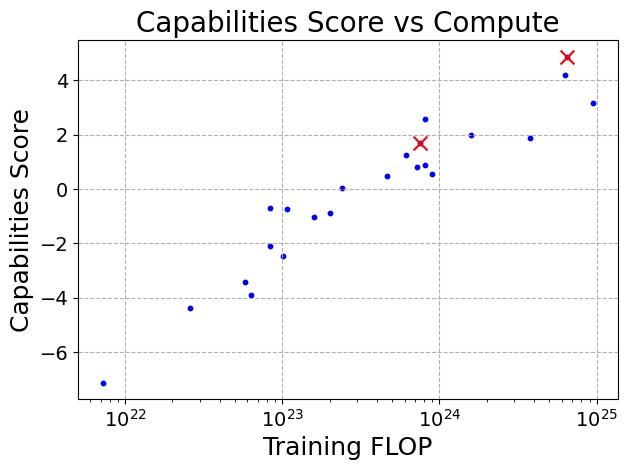

Pearson Correlation: nan
Spearman Correlation: nan


In [62]:
#%%
sns.reset_defaults()

def plot_compute_versus_score(model_df, evals_df, cap_names, label):
    """
    Plots the capabilities score against the compute of the model.
    """
    fig, ax = plt.subplots(1, 1)
    ax.scatter(model_df["FLOP"], model_df["score"], color='blue', s=10)
    ax.set_title(f"Capabilities Score vs Compute", fontsize=20)
    ax.set_xlabel("Training FLOP", fontsize=18)
    ax.set_ylabel("Capabilities Score", fontsize=18)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    # If it is Llama 3.1 b, mark it with an x
    for i, model in enumerate(model_df.index):
        if "Meta-Llama-3.1" in model:
            ax.scatter(model_df["FLOP"].iloc[i], model_df["score"].iloc[i], color='red', s=100, marker='x')
            # Add labels for Llama 3.1 8B and 70B
            # if "8B" in model:
            #     ax.text(model_df["FLOP"].iloc[i], model_df["score"].iloc[i], "Llama 3.1 8B", fontsize=12, color='red')
            # elif "70B" in model:
            #     ax.text(model_df["FLOP"].iloc[i], model_df["score"].iloc[i], "Llama 3.1 70B", fontsize=12, color='red')
    # Set log x axis
    ax.set_xscale('log')
    ax.grid(linestyle='--')
    fig.tight_layout()
    plt.show()

    pearson_corr, _ = stats.pearsonr(model_df["FLOP"], model_df["score"])
    spearman_corr, _ = stats.spearmanr(model_df["FLOP"], model_df["score"])

    print(f"Pearson Correlation: {pearson_corr}")
    print(f"Spearman Correlation: {spearman_corr}")

plot_compute_versus_score(combined_df, evals_df, cap_names, "Combined")

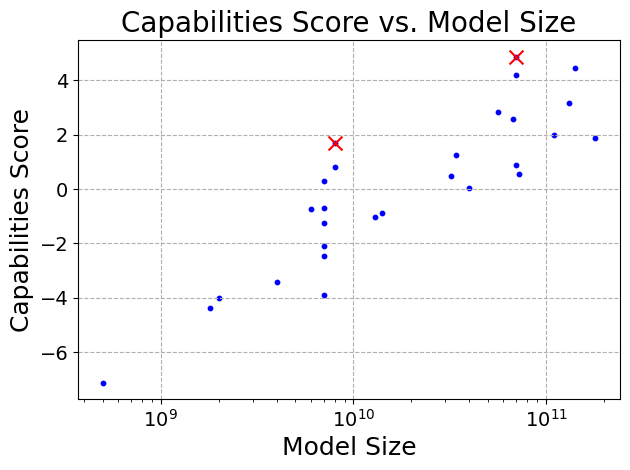

Pearson Correlation: 0.6816431755198556
Spearman Correlation: 0.8651754584372375


In [63]:
#%%

def plot_size_versus_score(model_df, evals_df, cap_names, label):
    """
    Plots the capabilities score against the size of the model.
    """
    fig, ax = plt.subplots(1, 1)
    ax.scatter(model_df["model_size"], model_df["score"], color='blue', s=10)
    ax.set_title(f"Capabilities Score vs. Model Size", fontsize=20)
    ax.set_xlabel("Model Size", fontsize=18)
    ax.set_ylabel("Capabilities Score", fontsize=18)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    # If it is Llama 3.1 b, mark it with an x
    for i, model in enumerate(model_df.index):
        if "Meta-Llama-3.1" in model:
            ax.scatter(model_df["model_size"].iloc[i], model_df["score"].iloc[i], color='red', s=100, marker='x')
    # Set log x axis
    ax.set_xscale('log')
    ax.grid(linestyle='--')
    fig.tight_layout()
    plt.show()

    pearson_corr, _ = stats.pearsonr(model_df["model_size"], model_df["score"])
    spearman_corr, _ = stats.spearmanr(model_df["model_size"], model_df["score"])

    print(f"Pearson Correlation: {pearson_corr}")
    print(f"Spearman Correlation: {spearman_corr}")

plot_size_versus_score(combined_df, evals_df, cap_names, "Combined")

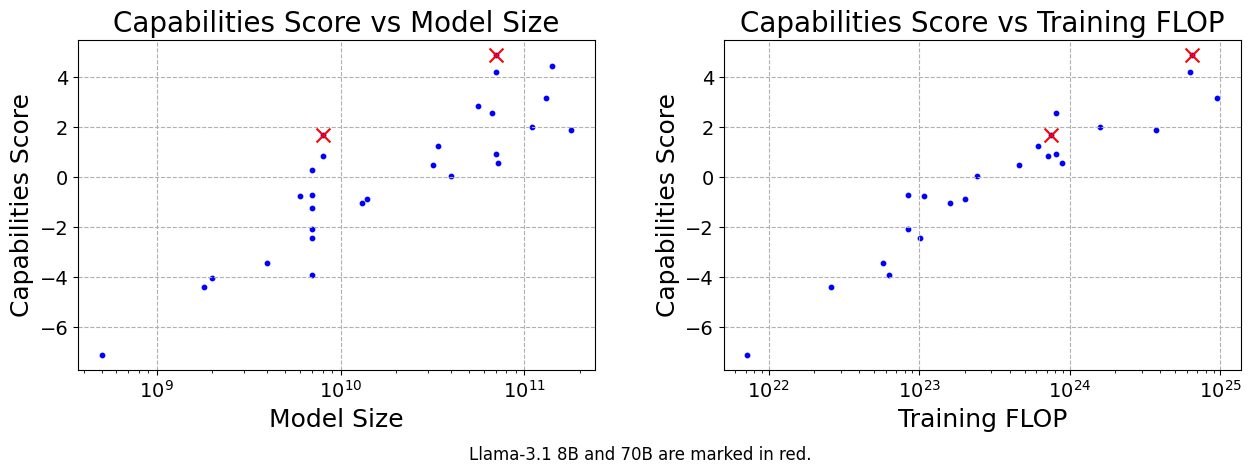

Model Size - Pearson Correlation: 0.6816431755198556
Model Size - Spearman Correlation: 0.8651754584372375
Training FLOP - Pearson Correlation: nan
Training FLOP - Spearman Correlation: nan


In [83]:
#%%
sns.reset_defaults()

def plot_compute_and_size_versus_score(model_df, evals_df, cap_names, label):
    """
    Plots the capabilities score against the compute and model size side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # Create a figure with 2 subplots side by side
    
    # Left plot: Capabilities Score vs Model Size
    ax = axes[0]
    ax.scatter(model_df["model_size"], model_df["score"], color='blue', s=10)
    ax.set_title(f"Capabilities Score vs Model Size", fontsize=20)
    ax.set_xlabel("Model Size", fontsize=18)
    ax.set_ylabel("Capabilities Score", fontsize=18)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    # Mark Llama 3.1 models with an 'x'
    for i, model in enumerate(model_df.index):
        if "Meta-Llama-3.1" in model:
            ax.scatter(model_df["model_size"].iloc[i], model_df["score"].iloc[i], color='red', s=100, marker='x')
    # Set log x axis
    ax.set_xscale('log')
    ax.grid(linestyle='--')

    # Right plot: Capabilities Score vs Compute
    ax = axes[1]
    ax.scatter(model_df["FLOP"], model_df["score"], color='blue', s=10)
    ax.set_title(f"Capabilities Score vs Training FLOP", fontsize=20)
    ax.set_xlabel("Training FLOP", fontsize=18)
    ax.set_ylabel("Capabilities Score", fontsize=18)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    # Mark Llama 3.1 models with an 'x'
    for i, model in enumerate(model_df.index):
        if "Meta-Llama-3.1" in model:
            ax.scatter(model_df["FLOP"].iloc[i], model_df["score"].iloc[i], color='red', s=100, marker='x')
    # Set log x axis
    ax.set_xscale('log')
    ax.grid(linestyle='--')

    fig.subplots_adjust(bottom=0.22)

    fig.text(0.5, 0.05, 'Llama-3.1 8B and 70B are marked in red.', ha='center', va='center', fontsize=12)

    # fig.subplots_adjust(bottom=0.10)
    # Adjust layout and show plot
    plt.subplots_adjust(wspace=0.25)  # Increase wspace to add more space between the plots
    # fig.tight_layout()
    plt.savefig("capabilities_vs_scale.pdf", format='pdf')
    plt.show()

    # Calculate and print correlations for both plots
    pearson_corr_size, _ = stats.pearsonr(model_df["model_size"], model_df["score"])
    spearman_corr_size, _ = stats.spearmanr(model_df["model_size"], model_df["score"])
    print(f"Model Size - Pearson Correlation: {pearson_corr_size}")
    print(f"Model Size - Spearman Correlation: {spearman_corr_size}")
    
    pearson_corr_flop, _ = stats.pearsonr(model_df["FLOP"], model_df["score"])
    spearman_corr_flop, _ = stats.spearmanr(model_df["FLOP"], model_df["score"])
    print(f"Training FLOP - Pearson Correlation: {pearson_corr_flop}")
    print(f"Training FLOP - Spearman Correlation: {spearman_corr_flop}")

    

plot_compute_and_size_versus_score(combined_df, evals_df, cap_names, "Combined")


In [65]:
#%%

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Define capability benchmarks
cap_names = ['bbh',
 'lambada_openai',
 'logiqa',
 'medqa_4options',
 'minerva_math',
 'piqa',
 'gsm8k',
 'hellaswag',
 'arc_challenge',
 'mmlu',
 'winogrande']

# ["logiqa", "piqa", "hellaswag", "winogrande", 'superglue_copa', "medqa_4options", "arc_challenge", "mmlu", "minerva_math", "lambada_openai", "gsm8k", "bbh"]

# common_sense = ['logiqa', 'piqa', 'hellaswag', 'winogrande', 'superglue_copa', 'lambada_openai', 'bbh']
# math = ['minerva_math', 'gsm8k']
# knowledge = ['mmlu', 'medqa_4options', 'arc_challenge']
# cap_names = math

def load_data():
    """
    Load data from CSV files and return as pandas DataFrames.
    """
    base_model_df = pd.read_csv('data/benchmarks_base_models.csv', index_col='model')
    chat_model_df = pd.read_csv('data/benchmarks_chat_models.csv', index_col='model')
    evals_df = pd.read_csv('data/benchmarks_info.csv', index_col='benchmark')
    return base_model_df, chat_model_df, evals_df

def find_nans(model_df):
    """
    Identifies and prints the locations of NaNs in the dataframe.
    """
    df_filtered = model_df.drop(columns=["model_size", "FLOP", "name", "type"])

    missing_fraction = df_filtered.isnull().mean().mean()
    print(f"Fraction missing data: {missing_fraction}")

    missing_data = df_filtered.isnull()
    missing_indices = missing_data.stack()[missing_data.stack()].index

    for row, col in missing_indices:
        print(f"Missing data at row {row}, column {col}")

# Load data and print missing values
base_model_df, chat_model_df, evals_df = load_data()
find_nans(base_model_df)
find_nans(chat_model_df)

Fraction missing data: 0.00021043771043771043
Missing data at row Yi-34B, column cyberseceval2_autocomplete
Fraction missing data: 0.001296456352636128
Missing data at row Qwen1.5-0.5B-Chat, column LMSYS_Chatbot_Arena
Missing data at row Qwen1.5-1.8B-Chat, column LMSYS_Chatbot_Arena
Missing data at row Yi-6B-Chat, column LMSYS_Chatbot_Arena
Missing data at row deepseek-llm-7b-chat, column LMSYS_Chatbot_Arena
Missing data at row falcon-40b-instruct, column LMSYS_Chatbot_Arena
Missing data at row falcon-7b-instruct, column LMSYS_Chatbot_Arena


In [66]:
#%%

llama = pd.read_csv("meta_llama_3_1_rows.csv", index_col = "Unnamed: 0")

combined_df = pd.concat([chat_model_df, llama], axis=0)

def get_non_nan_columns(df, index_label):
    if index_label not in df.index:
        raise ValueError(f"Index label '{index_label}' not found in DataFrame")
    return df.loc[index_label].index[df.loc[index_label].notna()].tolist()

combined_df.loc['Meta-Llama-3.1-70B-Instruct', 'type'] = 'chat'
combined_df.loc['Meta-Llama-3.1-70B-Instruct', 'name'] = 'Llama 3.1 70B Instruct'
combined_df.loc['Meta-Llama-3.1-70B-Instruct', 'model_size'] = 70e+9
combined_df.loc['Meta-Llama-3.1-70B-Instruct', 'FLOP'] = 6.52E+24

combined_df.loc['Meta-Llama-3.1-8B-Instruct', 'type'] = 'chat'
combined_df.loc['Meta-Llama-3.1-8B-Instruct', 'name'] = 'Llama 3.1 8B Instruct'
combined_df.loc['Meta-Llama-3.1-8B-Instruct', 'model_size'] = 8e+9
combined_df.loc['Meta-Llama-3.1-8B-Instruct', 'FLOP'] = 7.49e+23


get_non_nan_columns(combined_df, "Meta-Llama-3.1-70B-Instruct")

['bbh',
 'lambada_openai',
 'logiqa',
 'medqa_4options',
 'minerva_math',
 'piqa',
 'gsm8k',
 'hellaswag',
 'arc_challenge',
 'mmlu',
 'winogrande',
 'model_size',
 'FLOP',
 'name',
 'type']

In [67]:
#%%

##### RUN ANALYSIS ON BASE AND CHAT MODELS #####

def run_analysis(model_df, evals_df, cap_names, label, correlation_type = "spearman"):
    """
    Runs normalization, computes and plots correlation matrix, performs PCA, and prints analysis results. Returns modified evals_df and model_df, and eigenvalues and correlation matrix from PCA.

    We compute the correlation of each safety benchmark individually, dropping the rows that contains NaNs for each safety benchmark (if any).
    """

    # Normalize data
    normalized_df = model_df.drop(columns=["model_size", "FLOP", "name", "type"])
    normalized_df = normalized_df.dropna(axis=1, how='all')
    normalized_df = (normalized_df - normalized_df.mean()) / normalized_df.std(ddof=0)
    normalized_df = normalized_df.dropna(axis=1, how='all') # In case one column has a std dev of zero and became NaN during normalization

    df_cap = normalized_df[cap_names].copy().dropna() # capabilities evals dataframe
    safety_names = [col for col in normalized_df.columns if col not in cap_names]
    df_safety = normalized_df[safety_names].copy() # "safety" evals dataframe

    # Compute capabilities correlation matrix & statistics of correlations between capabilities benchmarks
    cap_matrix = df_cap.corr(method=correlation_type).to_numpy()
    triu_indices = np.triu_indices_from(cap_matrix, k=1)
    upper_tri_values = cap_matrix[triu_indices]
    mean_correlation = np.mean(upper_tri_values)
    std_dev_correlation = np.std(upper_tri_values)

    # Compute capabilities scores
    eigenvals, eigenvecs = np.linalg.eigh(cap_matrix)
    pc = eigenvecs[:, -1]
    pc = pc if np.abs(pc).max() == pc.max() else -pc
    model_cap_score = df_cap.to_numpy() @ pc

    # Update dataframes with capabilities scores
    df_safety["cap_score"] = model_cap_score
    df_cap["cap_score"] = model_cap_score
    evals_df_copy = evals_df.copy()

    # Compute correlations for each evaluation and update dataframes
    for safety_name in safety_names:
        safety_task_df = df_safety[[safety_name]].dropna() # Drop NaNs
        score_df = df_safety[["cap_score"]].loc[safety_task_df.index]
        reduced_df = pd.concat([safety_task_df, score_df], axis=1) # Concatenate with capabilities scores
        corr_value = reduced_df.corr(method=correlation_type).to_numpy()[0, 1] # 2x2 matrix where we take entry (0,1)
        evals_df_copy.loc[safety_name, f"{label}_{correlation_type}_correlations"] = corr_value # populate correlation column

    for cap_name in cap_names:
        cap_task_df = df_cap[[cap_name]].dropna()
        score_df = df_cap[["cap_score"]].loc[cap_task_df.index]
        reduced_df = pd.concat([cap_task_df, score_df], axis=1)
        corr_value = reduced_df.corr(method=correlation_type).to_numpy()[0, 1]
        evals_df_copy.loc[cap_name, f"{label}_{correlation_type}_correlations"] = corr_value
    
    # Calculate total variance explained
    variance_explained_pc1 = eigenvals[-1] / np.sum(eigenvals)

    # Print analysis results
    print(f"\n***** Results for {label} *****")
    print(f"Mean correlation between two capabilities benchmarks: {mean_correlation*100:.1f}")
    print(f"Standard deviation of correlation between two capabilities benchmarks: {std_dev_correlation*100:.1f}")
    print(f"Total capabilities variance explained from PC1: {variance_explained_pc1*100:.1f}")

    print("\nCAPABILITIES CORRELATIONS:")
    for cap_name in cap_names:
        print(f"{cap_name} {100*evals_df_copy.loc[cap_name, f'{label}_{correlation_type}_correlations']:.2f}")

    print("\nSAFETY CORRELATIONS:")
    for safety_name in safety_names:
        print(f"{safety_name} {100*evals_df_copy.loc[safety_name, f'{label}_{correlation_type}_correlations']:.1f}")

    print("\nMODEL SCORES:")
    model_cap_dict = dict(sorted(list(zip(model_df.index, model_cap_score)), key=lambda item: item[1]))
    for k, v in model_cap_dict.items():
        print(f"{k}, {v:.2f}")

    # Update model dataframe with scores
    model_df_copy = model_df.copy()
    model_df_copy["score"] = model_cap_score

    return evals_df_copy, model_df_copy, eigenvals, cap_matrix

# evals_df, base_model_df, base_eigenvals, base_cap_matrix = run_analysis(base_model_df, evals_df, cap_names, "Base", "spearman")
evals_df, combined_df, chat_eigenvals, chat_cap_matrix = run_analysis(combined_df, evals_df, cap_names, "Chat", "spearman")


***** Results for Chat *****
Mean correlation between two capabilities benchmarks: 68.1
Standard deviation of correlation between two capabilities benchmarks: 13.4
Total capabilities variance explained from PC1: 71.3

CAPABILITIES CORRELATIONS:
bbh 82.43
lambada_openai 80.46
logiqa 87.42
medqa_4options 90.80
minerva_math 64.70
piqa 88.82
gsm8k 82.65
hellaswag 80.46
arc_challenge 85.22
mmlu 85.66
winogrande 89.49

SAFETY CORRELATIONS:
machiavelli-points 64.0
machiavelli-achievements 66.4
machiavelli-steps 14.5
machiavelli-game.score 54.0
machiavelli-power.money -68.1
machiavelli-power.physical 10.1
machiavelli-power.social -52.5
machiavelli-power.utility -22.1
machiavelli-power.Σ -43.8
machiavelli-utility.suffering -48.4
machiavelli-utility.Σ -48.4
machiavelli-violations.deception -11.1
machiavelli-violations.fairness -45.8
machiavelli-violations.intending_harm -33.9
machiavelli-violations.killing -60.9
machiavelli-violations.manipulation -17.3
machiavelli-violations.non_physical_harm 

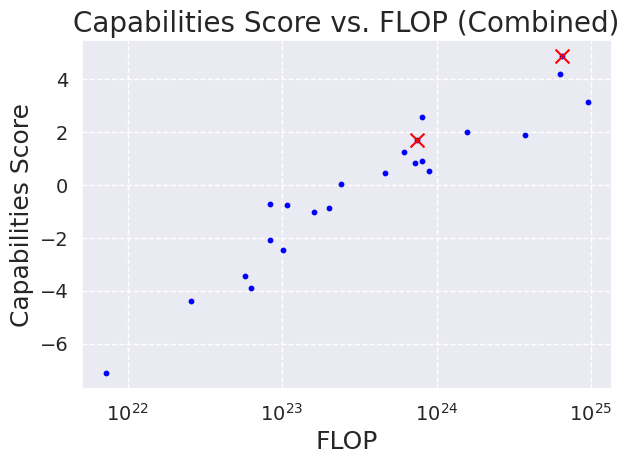

Pearson Correlation: nan
Spearman Correlation: nan


In [15]:
#%%


def plot_compute_versus_score(model_df, evals_df, cap_names, label):
    """
    Plots the capabilities score against the compute of the model.
    """
    fig, ax = plt.subplots(1, 1)
    ax.scatter(model_df["FLOP"], model_df["score"], color='blue', s=10)
    ax.set_title(f"Capabilities Score vs. FLOP ({label})", fontsize=20)
    ax.set_xlabel("FLOP", fontsize=18)
    ax.set_ylabel("Capabilities Score", fontsize=18)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    # If it is Llama 3.1 b, mark it with an x
    for i, model in enumerate(model_df.index):
        if "Meta-Llama-3.1" in model:
            ax.scatter(model_df["FLOP"].iloc[i], model_df["score"].iloc[i], color='red', s=100, marker='x')
    # Set log x axis
    ax.set_xscale('log')
    ax.grid(linestyle='--')
    fig.tight_layout()
    plt.show()

    pearson_corr, _ = stats.pearsonr(model_df["FLOP"], model_df["score"])
    spearman_corr, _ = stats.spearmanr(model_df["FLOP"], model_df["score"])

    print(f"Pearson Correlation: {pearson_corr}")
    print(f"Spearman Correlation: {spearman_corr}")

plot_compute_versus_score(combined_df, evals_df, cap_names, "Combined")

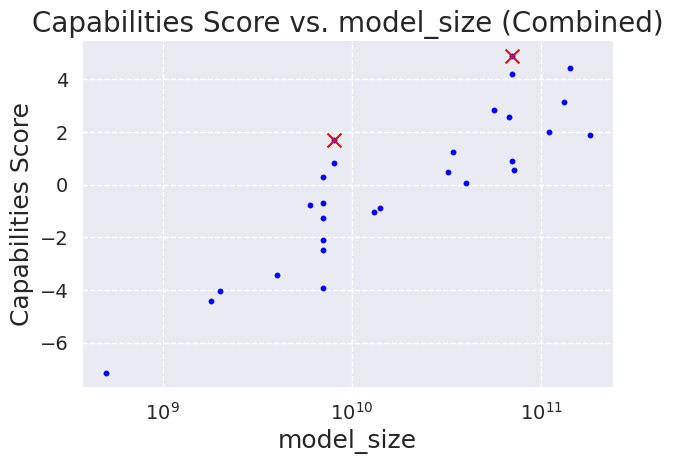

Pearson Correlation: 0.6816431755198556
Spearman Correlation: 0.8651754584372375


In [16]:
#%%

def plot_size_versus_score(model_df, evals_df, cap_names, label):
    """
    Plots the capabilities score against the size of the model.
    """
    fig, ax = plt.subplots(1, 1)
    ax.scatter(model_df["model_size"], model_df["score"], color='blue', s=10)
    ax.set_title(f"Capabilities Score vs. model_size ({label})", fontsize=20)
    ax.set_xlabel("model_size", fontsize=18)
    ax.set_ylabel("Capabilities Score", fontsize=18)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    # If it is Llama 3.1 b, mark it with an x
    for i, model in enumerate(model_df.index):
        if "Meta-Llama-3.1" in model:
            ax.scatter(model_df["model_size"].iloc[i], model_df["score"].iloc[i], color='red', s=100, marker='x')
    # Set log x axis
    ax.set_xscale('log')
    ax.grid(linestyle='--')
    fig.tight_layout()
    plt.show()

    pearson_corr, _ = stats.pearsonr(model_df["model_size"], model_df["score"])
    spearman_corr, _ = stats.spearmanr(model_df["model_size"], model_df["score"])

    print(f"Pearson Correlation: {pearson_corr}")
    print(f"Spearman Correlation: {spearman_corr}")

plot_size_versus_score(combined_df, evals_df, cap_names, "Combined")